In [16]:
import os
from pprint import pprint

import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
print(f"{torch.__version__=}")

if os.path.abspath("..") not in os.sys.path:
    os.sys.path.append(os.path.abspath(".."))

from src.output import plot_predictions
from src.linear_regression import LinearRegressionModel
from src.linear_regression import LinearRegressionModelV2

torch.__version__='2.8.0+cu128'


In [2]:
# Create *known* parameters
weight = 0.8
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3160],
         [0.3320],
         [0.3480],
         [0.3640],
         [0.3800],
         [0.3960],
         [0.4120],
         [0.4280],
         [0.4440]]))

In [3]:
# Create train/test split
train_split = int(0.7 * len(X))  # 80% of data used for training set, 20% for testing
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(35, 35, 15, 15)

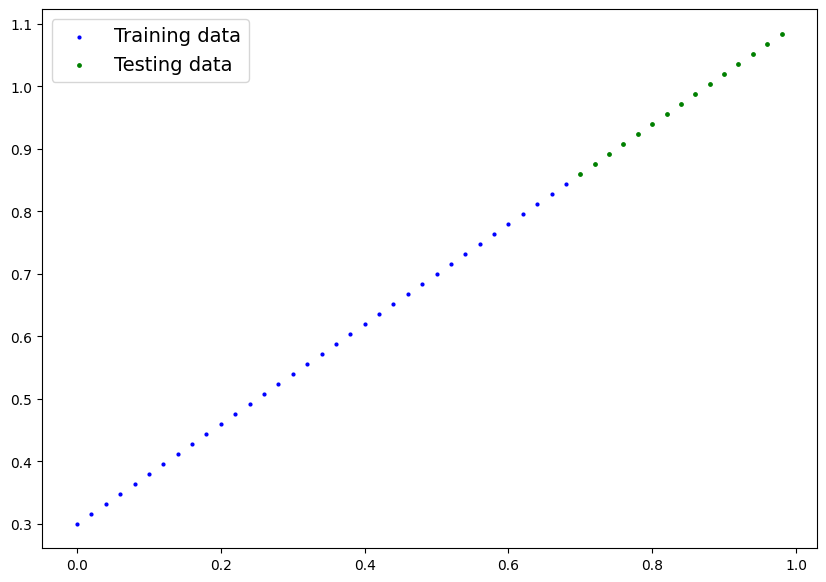

In [4]:
plot_predictions(X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test);

# Version 1

In [5]:
# Set manual seed since nn.Parameter are randomly initialized
# torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([-0.8348], requires_grad=True),
 Parameter containing:
 tensor([-0.5937], requires_grad=True)]

In [6]:
# List named parameters
model_0.state_dict()

OrderedDict([('weights', tensor([-0.8348])), ('bias', tensor([-0.5937]))])

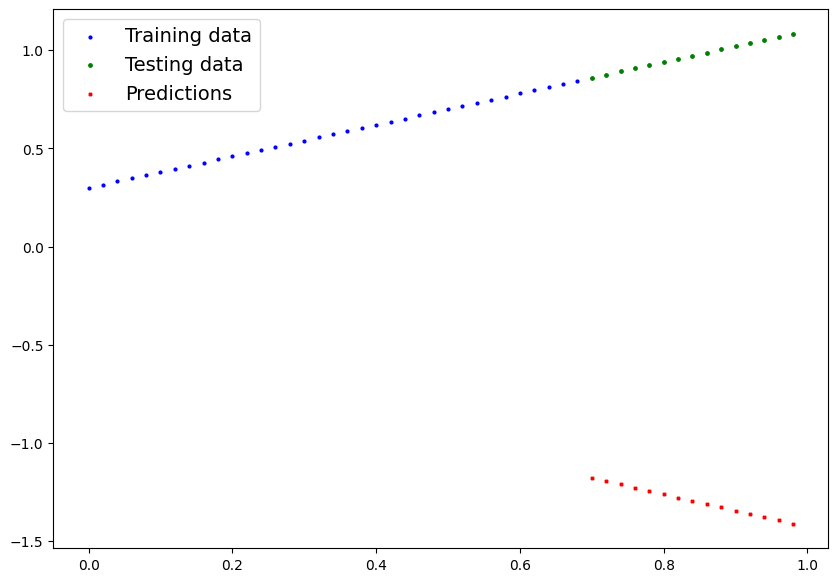

In [7]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)
plot_predictions(
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=y_preds
);

In [8]:
# torch.manual_seed(42)

# Create the loss function
loss_fn = nn.L1Loss()  # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001)

epochs = 10000

train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
        # 1. Forward pass on test data
        test_pred = model_0(X_test)

        # 2. Caculate loss on test data
        test_loss = loss_fn(
            test_pred, y_test.type(torch.float)
        )  # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

        # Print out what's happening
        epoch_count.append(epoch)
        train_loss_values.append(loss.detach().numpy())
        test_loss_values.append(test_loss.detach().numpy())
        if epoch % 10 == 0:
            print(
                f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} "
            )

Epoch: 0 | MAE Train Loss: 1.4495267868041992 | MAE Test Loss: 2.265634059906006 
Epoch: 10 | MAE Train Loss: 1.4383708238601685 | MAE Test Loss: 2.2527785301208496 
Epoch: 20 | MAE Train Loss: 1.4272149801254272 | MAE Test Loss: 2.2399227619171143 
Epoch: 30 | MAE Train Loss: 1.4160593748092651 | MAE Test Loss: 2.227066993713379 
Epoch: 40 | MAE Train Loss: 1.404903531074524 | MAE Test Loss: 2.2142114639282227 
Epoch: 50 | MAE Train Loss: 1.3937475681304932 | MAE Test Loss: 2.201355457305908 
Epoch: 60 | MAE Train Loss: 1.3825918436050415 | MAE Test Loss: 2.188499927520752 
Epoch: 70 | MAE Train Loss: 1.3714361190795898 | MAE Test Loss: 2.1756443977355957 
Epoch: 80 | MAE Train Loss: 1.360280156135559 | MAE Test Loss: 2.1627886295318604 
Epoch: 90 | MAE Train Loss: 1.3491243124008179 | MAE Test Loss: 2.149932622909546 
Epoch: 100 | MAE Train Loss: 1.3379687070846558 | MAE Test Loss: 2.1370768547058105 
Epoch: 110 | MAE Train Loss: 1.326812744140625 | MAE Test Loss: 2.1242213249206543 

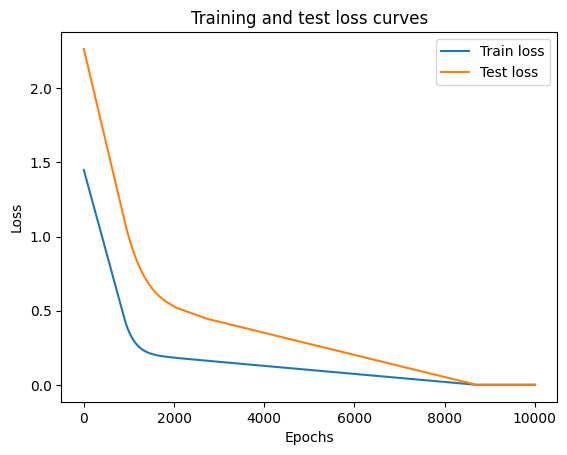

In [9]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [10]:
model_0.eval()

with torch.inference_mode():
    y_preds = model_0(X_test)
y_preds

tensor([[0.8594],
        [0.8753],
        [0.8913],
        [0.9073],
        [0.9233],
        [0.9393],
        [0.9553],
        [0.9713],
        [0.9872],
        [1.0032],
        [1.0192],
        [1.0352],
        [1.0512],
        [1.0672],
        [1.0832]])

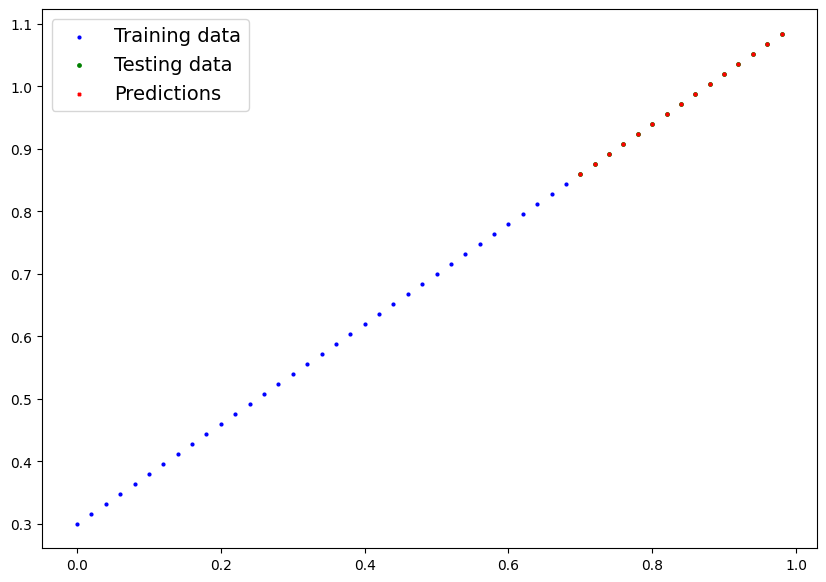

In [11]:
plot_predictions(
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=y_preds
);

In [12]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.7993])), ('bias', tensor([0.2999]))])

# Version 2

In [13]:
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[-0.8940]])),
              ('linear_layer.bias', tensor([-0.7910]))]))

In [14]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(
    params=model_1.parameters(),  # optimize newly created model's parameters
    lr=0.01,
)

In [ ]:
torch.manual_seed(42)


epochs = 1000


for epoch in range(epochs):
    ### Training
    model_1.train()  # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()  # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 1.6669586896896362 | Test loss: 2.5011255741119385
Epoch: 100 | Train loss: 0.5513582229614258 | Test loss: 1.2155240774154663
Epoch: 200 | Train loss: 0.18946430087089539 | Test loss: 0.5582910776138306
Epoch: 300 | Train loss: 0.15998466312885284 | Test loss: 0.43717944622039795
Epoch: 400 | Train loss: 0.13273753225803375 | Test loss: 0.3627510070800781
Epoch: 500 | Train loss: 0.10549234598875046 | Test loss: 0.2875785827636719
Epoch: 600 | Train loss: 0.07825087010860443 | Test loss: 0.21315224468708038
Epoch: 700 | Train loss: 0.05100935697555542 | Test loss: 0.13872668147087097
Epoch: 800 | Train loss: 0.023767679929733276 | Test loss: 0.06430231779813766
Epoch: 900 | Train loss: 0.0027510719373822212 | Test loss: 0.00707633513957262


In [17]:
# pprint = pretty print, see: https://docs.python.org/3/library/pprint.html
print("The model learned the following values for weights and bias:")
pprint(model_1.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")

The model learned the following values for weights and bias:
OrderedDict([('linear_layer.weight', tensor([[0.7939]])),
             ('linear_layer.bias', tensor([0.2993]))])

And the original values for weights and bias are:
weights: 0.8, bias: 0.3


In [18]:
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[0.8551],
        [0.8709],
        [0.8868],
        [0.9027],
        [0.9186],
        [0.9345],
        [0.9503],
        [0.9662],
        [0.9821],
        [0.9980],
        [1.0139],
        [1.0297],
        [1.0456],
        [1.0615],
        [1.0774]])

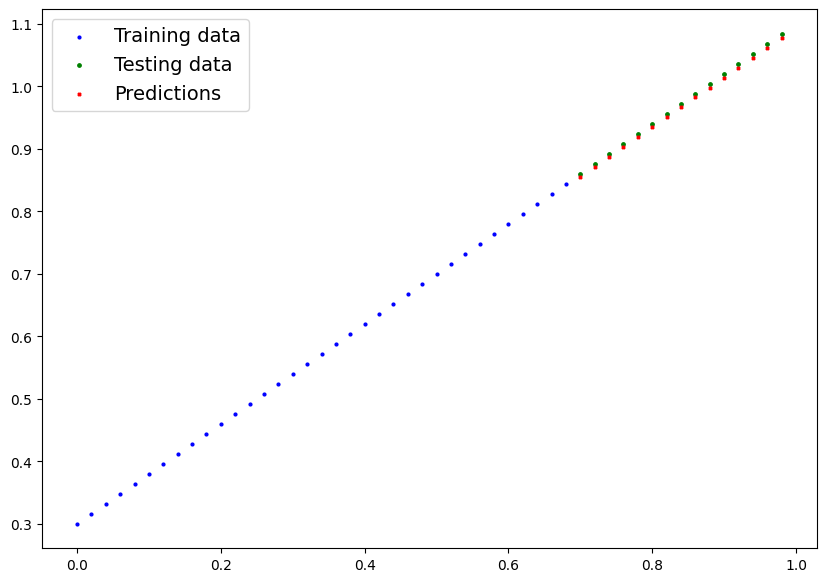

In [19]:
plot_predictions(
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, predictions=y_preds
);